# 숙제 3

데이터과학 입문

한상문 (서울대학교 통계학과)  
June 2026

## R

``` r
# install.packages(c("reticulate", "tidyverse", "Lahman", "NHANES", "mosaic", "dplyr", "tidyr", "MASS" "patchwork"))

library(tidyverse)
library(Lahman)
library(NHANES)
library(mosaic)
library(dplyr)
library(tidyr)
library(patchwork)

#if (!dir.exists("data")) dir.create("data")

# 데이터를 csv로 저장
# write.csv(NHANES, "data/NHANES.csv", row.names = FALSE)
```

## Python

``` python
import numpy as np
import pandas as pd
import polars as pl
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.stats import chi2, t
from plotnine import *
import patchworklib as pw
import pylahman
```

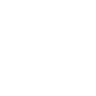

## 지시사항

제출마감 2026-06-15 23:00

1.  R과 Python을 모두 사용하여 사용된 코드와 데이터랭글링 절차,
    분석결과를 설명한다. 두 언어의 분석결과가 차이가 있으면 그 이유를
    설명한다.
2.  [Quarto
    Markdown](https://quarto.org/docs/authoring/markdown-basics.html)을
    사용한다. 제공된 숙제 `.qmd` 파일에 본인의 답안을 “답안” 절에
    추가하여 제출한다. Quarto Markdown은 RStudio 또는 Visual Studio
    Code에 [Quarto
    Extension](https://marketplace.visualstudio.com/items?itemName=quarto.quarto)을
    추가하여 컴파일, 다른 문서 형식으로 변환할 수 있다.
3.  R의 `reticulate` 패키지를 사용하면 하나의 `.qmd` 파일 안에서 R과
    Python을 동시에 사용할 수 있다. 이때 다음 문법을 사용하여 두 언어
    코드를 탭으로 구분한다. 숙제 `.qmd` 파일은 `reticulate`을 사용하도록
    준비되어 있다.

```` markdown
::: {.panel-tabset}

## R

```{r}
R code
```

## Python

```{python}
Python code
```

:::
````

1.  `.qmd`를 컴파일하여 생성된 `.html` 파일을 함께 저장소에 제출한다.
2.  함께 제공된 `student.yml`을 함께 작성하여 저장소에 제출한다.

## 평가 기준

1.  재현성: 제출된 저장소의 `.qmd` 파일을 컴파일하여 함께 제출된 `.html`
    파일과 동일한 결과가 나와야 한다.
2.  분석의 정확성: 분석은 올바른 기술적 세부 사항을 포함하여 수행되어야
    한다.
3.  보고서의 전반적인 품질: 데이터 가공 및 분석 결과가 명확하고 자세하게
    설명되어야 한다.
4.  코드의 전반적인 품질: 코드는 체계적으로 정리되어 있어야 하며,
    가독성을 높이기 위해 적절한 주석이 포함되어야 한다.

#### **늦게 제출된 과제물은 받지 않는다.**

# 1부 교과서 연습문제

## 문제 1-1

1.  MDSR 10장 연습문제 10.6.6

- Smoking is an important public health concern.
- Use the NHANES data from the NHANES package to develop a logistic
  regression model that identifies predictors of current smoking among
  those 20 or older. (Hint: note that the SmokeNow variable is missing
  for those who have never smoked: you will need to recode the variable
  to construct your outcome variable.)

### 답안

- `NHANES` 패키지의 `SmokeNow` 변수는 평생 100개비 이상 흡연한 적이 있는
  성인(20세 이상)에게만 “현재 규칙적으로 흡연하는지”를 묻는 변수이다.
- 한 번도 100개비 이상 피우지 않은 사람(`Smoke100 == "No"`)에게는
  `SmokeNow`가 `NA`로 기록되어 있으므로, 이들을 현재 비흡연자(`No`)로
  재코딩해야 한다.
- 반응변수는 20세 이상 대상자에 대해 `current_smoker`를 다음과 같이
  정의하였다.
  - `Smoke100 == "No"` (비흡연 경험 없음) → `0`
  - `SmokeNow == "Yes"` (현재 흡연) → `1`
  - `SmokeNow == "No"` (과거 흡연, 현재 비흡연) → `0`
- 교과서에서 제시한 `SmokeNow`와 `Smoke100`의 교차표를 확인하면, `NA`
  값이 모두 `Smoke100 == "No"`인 비흡연 경험자에 해당함을 알 수 있다.
- 설명변수는 중복 정보를 피하고 해석을 단순화하기 위해 아래와 같이
  선택하였다.
  - 범주형 (2수준): `Gender`, `PhysActive`, `Alcohol12PlusYr`
  - 연속형: `Age` (`AgeDecade`, `AgeMonths` 대신), `Poverty`
    (`HHIncome`, `HHIncomeMid` 대신), `BMI` (`Weight`, `Height`,
    `BMI_WHO` 대신)

------------------------------------------------------------------------

## R

``` r
# 성인 데이터 필터링
nhanes_adults <- NHANES %>%
  filter(Age >= 20)

# 변수 교차표 확인
# SmokeNow와 Smoke100의 교차표를 통해 NA 값이 모두 Smoke100 == "No"인 비흡연 경험자에 해당함을 확인
mosaic::tally(~ SmokeNow + Smoke100, data = nhanes_adults)
```

            Smoke100
    SmokeNow   No  Yes
        No      0 1745
        Yes     0 1466
        <NA> 4024    0

## Python

``` python
# 데이터 불러오기
NHANES = pl.read_csv(
    "data/NHANES.csv",
    schema_overrides={
        "Age": pl.Float64,
        "Poverty": pl.Float64,
        "BMI": pl.Float64
    },
    null_values=["NA", " ", "null", ""],
    infer_schema_length=None
)

# 성인 데이터 필터링
nhanes_adults = NHANES.filter(pl.col("Age") >= 20)

# 변수 교차표 확인
# SmokeNow와 Smoke100의 교차표를 통해 NA 값이 모두 Smoke100 == "No"인 비흡연 경험자에 해당함을 확인
smoke_tally = pd.crosstab(
    nhanes_adults.to_pandas()["SmokeNow"].fillna("NA"),
    nhanes_adults.to_pandas()["Smoke100"].fillna("NA")
)

smoke_tally.index.name = "SmokeNow"
smoke_tally.columns.name = "Smoke100"

print(smoke_tally)
```

    Smoke100    No   Yes
    SmokeNow            
    NA        4024     0
    No           0  1745
    Yes          0  1466

- 먼저, 20세 이상 성인 데이터를 필터링한 뒤, `SmokeNow`와 `Smoke100`의
  교차표를 확인하여 `NA` 값이 모두 `Smoke100 == "No"`인 비흡연 경험자에
  해당함을 확인하였다.
- 이후, `SmokeNow`와 `Smoke100`을 재코딩하여 `current_smoker`라는 새로운
  이진 변수로 만들어 로지스틱 회귀 모델에 적합하였다.

## R

``` r
# 변수 재코딩 및 결측치 제거
# nhanes_fixed 데이터 프레임에 current_smoker 변수에는 0이 5769명, 1이 1466명으로 총 6994명의 성인 데이터가 포함되어 있다.
nhanes_fixed <- nhanes_adults %>%
  mutate(
    SmokeNow_recode = ifelse(Smoke100 == "No", "No", as.character(SmokeNow)),
    current_smoker = ifelse(SmokeNow_recode == "Yes", 1L, 0L)
  ) %>%
  select(
    current_smoker, Gender, PhysActive, Alcohol12PlusYr,
    Age, Poverty, BMI
  ) %>%
  drop_na()

# drop된 표본 수
# print(nrow(nhanes_adults) - nrow(nhanes_fixed)) # 1238

# nhanes_fixed의 총 표본 수(5997), 흡연자(1206명)와 비흡연자(4791명) 수
# print(nrow(nhanes_fixed))
# print(nrow(nhanes_fixed[nhanes_fixed$current_smoker == 1,]))
# print(nrow(nhanes_fixed[nhanes_fixed$current_smoker == 0,]))

# 흡연 비율 출력 => 0.2011
# print(round(mean(nhanes_fixed$current_smoker), 4)) # nhanes_fixed의 흡연 비율 => 0.2011

# 로지스틱 회귀 모델 적합
model_smoke <- glm(
  current_smoker ~ Gender + PhysActive + Alcohol12PlusYr + Age + Poverty + BMI,
  data = nhanes_fixed,
  family = "binomial"
)

# 모델 적합 결과 저장 및 합치기
summary_coef <- summary(model_smoke)$coefficients
odds_ratios <- exp(coef(model_smoke))
conf_intervals <- exp(confint(model_smoke))

combined_results <- data.frame(
  summary_coef,
  Odds_Ratio = odds_ratios,
  conf_intervals
)

colnames(combined_results)[6:7] <- c("CI_2.5%", "CI_97.5%")

# 분석 결과 출력
print(round(combined_results, 4))
```

                       Estimate Std..Error  z.value Pr...z.. Odds_Ratio CI_2.5%
    (Intercept)          0.5039     0.2236   2.2535   0.0242     1.6551  1.0673
    Gendermale           0.1988     0.0697   2.8515   0.0044     1.2200  1.0643
    PhysActiveYes       -0.8526     0.0729 -11.6884   0.0000     0.4263  0.3693
    Alcohol12PlusYrYes   1.3608     0.1164  11.6913   0.0000     3.8993  3.1188
    Age                 -0.0185     0.0022  -8.5347   0.0000     0.9816  0.9774
    Poverty             -0.2860     0.0221 -12.9569   0.0000     0.7513  0.7193
    BMI                 -0.0385     0.0056  -6.8961   0.0000     0.9622  0.9516
                       CI_97.5%
    (Intercept)          2.5647
    Gendermale           1.3990
    PhysActiveYes        0.4916
    Alcohol12PlusYrYes   4.9240
    Age                  0.9858
    Poverty              0.7843
    BMI                  0.9727

## Python

``` python
# 변수 재코딩 및 결측치 제거
# nhanes_fixed 데이터 프레임에 current_smoker 변수에는 0이 5769명, 1이 1466명으로 총 6994명의 성인 데이터가 포함되어 있다.
nhanes_fixed = (
    nhanes_adults
    .with_columns(
        pl.when(pl.col("Smoke100").is_null())
        .then(pl.lit(None, dtype=pl.Utf8))
        .when(pl.col("Smoke100") == "No")
        .then(pl.lit("No"))
        .otherwise(pl.col("SmokeNow").cast(pl.Utf8))
        .alias("SmokeNow_recode")
    )
    .with_columns(
        pl.when(pl.col("SmokeNow_recode").is_null())
        .then(pl.lit(None, dtype=pl.Int64))
        .when(pl.col("SmokeNow_recode") == "Yes")
        .then(pl.lit(1))
        .otherwise(pl.lit(0))
        .alias("current_smoker")
    )
    .select([
        "current_smoker", "Gender", "PhysActive", "Alcohol12PlusYr",
        "Age", "Poverty", "BMI"
    ])
    .drop_nulls()
)

# drop된 표본 수
# print(nhanes_adults.height - nhanes_fixed.height) # 1238

# nhanes_fixed의 총 표본 수(5997), 흡연자(1206명)와 비흡연자(4791명) 수
# print(nhanes_fixed.height)
# print(nhanes_fixed.filter(pl.col("current_smoker") == 1).height)
# print(nhanes_fixed.filter(pl.col("current_smoker") == 0).height)

# 흡연 비율 출력 => 0.2011
# print(round(nhanes_fixed.select(pl.col("current_smoker").mean()).item(), 4)) 

# statsmodels에서 범주형 변수를 처리하기 위해 pandas 데이터프레임으로 변환
nhanes_fixed = nhanes_fixed.to_pandas()

# R의 기준 범주와 같아지도록 범주 순서를 지정
nhanes_fixed["Gender"] = pd.Categorical(nhanes_fixed["Gender"], categories=["female", "male"])
nhanes_fixed["PhysActive"] = pd.Categorical(nhanes_fixed["PhysActive"], categories=["No", "Yes"])
nhanes_fixed["Alcohol12PlusYr"] = pd.Categorical(nhanes_fixed["Alcohol12PlusYr"], categories=["No", "Yes"])

# 로지스틱 회귀 모델 적합
model_smoke = smf.glm(
    formula=(
        "current_smoker ~ "
        "C(Gender, Treatment(reference='female')) + "
        "C(PhysActive, Treatment(reference='No')) + "
        "C(Alcohol12PlusYr, Treatment(reference='No')) + "
        "Age + Poverty + BMI"
    ),
    data=nhanes_fixed,
    family=sm.families.Binomial()
).fit()

# 모델 적합 결과 저장 및 합치기
summary_coef = pd.DataFrame({
    "Estimate": model_smoke.params,
    "Std_Error": model_smoke.bse,
    "z_value": model_smoke.tvalues,
    "Pr(>|z|)": model_smoke.pvalues
})

odds_ratios = np.exp(model_smoke.params).rename("Odds_Ratio")
conf_intervals = np.exp(model_smoke.conf_int())
conf_intervals.columns = ["CI_2.5%", "CI_97.5%"]

combined_results = pd.concat(
    [summary_coef, odds_ratios, conf_intervals],
    axis=1
)

# 행 이름 맞추기
combined_results = combined_results.rename(index={
    "Intercept": "(Intercept)",
    "C(Gender, Treatment(reference='female'))[T.male]": "Gendermale",
    "C(PhysActive, Treatment(reference='No'))[T.Yes]": "PhysActiveYes",
    "C(Alcohol12PlusYr, Treatment(reference='No'))[T.Yes]": "Alcohol12PlusYrYes"
})

# 분석 결과 출력
print(round(combined_results, 4))
```

                        Estimate  Std_Error  z_value  ...  Odds_Ratio  CI_2.5%  CI_97.5%
    (Intercept)           0.5039     0.2236   2.2535  ...      1.6551   1.0678    2.5654
    Gendermale            0.1988     0.0697   2.8515  ...      1.2200   1.0641    1.3986
    PhysActiveYes        -0.8526     0.0729 -11.6884  ...      0.4263   0.3695    0.4918
    Alcohol12PlusYrYes    1.3608     0.1164  11.6913  ...      3.8993   3.1039    4.8985
    Age                  -0.0185     0.0022  -8.5347  ...      0.9816   0.9775    0.9858
    Poverty              -0.2860     0.0221 -12.9569  ...      0.7513   0.7195    0.7845
    BMI                  -0.0385     0.0056  -6.8961  ...      0.9622   0.9517    0.9728

    [7 rows x 7 columns]

- 분석에 포함된 모든 설명변수의 유의확률(p-value)이 0.05 미만으로
  나타났다.
- 또한 모든 변수의 95% 신뢰구간(CI_2.5% ~ CI_97.5%)이 1을 포함하지
  않으므로, 선택된 6개의 변수 모두 20세 이상 성인의 현재 흡연 여부를
  예측하는 데 통계적으로 매우 유의미한 변수이다.
- 흡연 확률을 높이는 주요 요인 (`Odds_Ratio` \> 1)
  - 음주 경험 (Alcohol12PlusYr): `Odds_Ratio`가 3.8993으로 가장 높다.
    지난 1년간 음주 경험이 있는 성인은 경험이 없는 성인에 비해 현재
    흡연자일 오즈(Odds)가 약 3.9배 높다.
  - 성별 (Gender): `Odds_Ratio`가 1.2200으로, 남성이 여성에 비해
    흡연자일 오즈가 약 1.22배 높다.
- 흡연 확률을 낮추는 요인 (`Odds_Ratio` \< 1)
  - 신체 활동 (PhysActive): 평소 규칙적인 신체 활동을 하는 성인은 하지
    않는 성인에 비해 흡연자일 오즈가 약 0.43배로 크게 낮아진다.
  - 가구 소득 수준 (Poverty): 빈곤 지수(소득 대비 생계비 비율)가 1단위
    증가할수록 (즉, 경제적 수준이 양호할수록) 흡연자일 오즈가 약
    0.75배로 감소한다.
  - 연령 (Age) 및 체질량지수 (BMI): 연령이 1세 증가할 때마다, BMI가
    1단위 증가할 때마다 현재 흡연자일 오즈가 각각 0.98배, 0.96배로 소폭
    감소하는 경향을 보인다.
- 결론
  - 성인의 현재 흡연 여부를 예측하는 모델을 구축한 결과, 과거 1년간의
    음주 경험이 흡연의 가장 강력한 예측(위험) 요인으로 식별되었다.
  - 반면 규칙적인 신체 활동과 높은 경제적 수준은 흡연 확률을 낮추는
    요인임을 확인할 수 있다.

# 2부 데이터 분석 실무

### 분석 관련 공통 지침

1.  관측단위(observational unit)는 `playerID`와 `yearID`의 고유한
    조합으로 한다. 즉, 데이터프레임의 각 행은 한 선수의 특정 연도에
    해당해야 하고(예: 2019년 류현진), 한 선수의 특정 연도가 두 번 이상
    나타나서는 안 된다. 이적을 한 경우 원자료에서는 두 번 이상 나타날 수
    있으므로 주의해야 한다.
2.  데이터 분석을 하는 중에 필요한 경우 pivoting으로 각 행이 한명의
    선수에 해당하는 wide format data를 만들어서 연도간 비교를 하는 것은
    허용한다.

## 문제 2-1

Lahman Package의 `Teams` 데이터프레임에서 코로나 시즌인 2020년을 제외한
2010년부터 2025년 사이의 데이터를 이용하여 다음 질문에 답하라.

1.  MDSR Chapter 7 Iteration 에서 배운 Bill James의 공식을 변형한 다음
    모형을 데이터에 적합하고, 모수 $k$의 점추정치와 신뢰구간을 구하라.
    $$  WPct = \frac{RS^k}{S^k+RA^k} = \frac{1}{1+(RA/RS)^k}$$

### 답안

- Lahman 패키지의 Teams 데이터셋을 불러온 뒤 filter() 함수를 사용하여
  2010년부터 2025년 데이터 중 2020년을 제외하고 추출한다.
- 기존에 제시된 공식에 사용되는 변수들을 준비하기 위해, `WPct` 변수를
  계산하고, 득점을 나타내는 `RS` 변수(원 데이터의 R)를 준비한다.
- 여기서 RS는 팀이 시즌 동안 득점한 총 점수(Runs Scored)를 나타내며,
  RA는 팀이 시즌 동안 허용한 총 점수(Runs Allowed)를 나타낸다.
- 모형이 선형이 아닌 $WPct = \frac{1}{1+(RA/RS)^k}$ 형태이므로, 강의
  자료를 참고하여 비선형 최소제곱법을 수행하는 `nls()` 함수를 사용하여
  모델을 적합한다.

## R

``` r
# 강의 자료에서 제시된 Bill James의 공식에 따른 함수 정의
bill_james <- function(x, k) {
  1 / (1 + (1 / x)^k)
}


# 데이터 필터링 및 변수명 변경
teams_filtered <- Teams %>%
  filter(yearID >= 2010, yearID <= 2025, yearID != 2020) %>%
  rename(RS = R) %>%
  mutate(
    WPct = W / (W + L),
    run_ratio = RS / RA
  ) %>%
  select(yearID, teamID, lgID, WPct, run_ratio, RS, RA, W, L)

# nls로 모형 적합
model_bill_james <- nls(
  WPct ~ bill_james(run_ratio, k), 
  data = teams_filtered, 
  start = list(k = 2)
)

# 결과 저장 및 합치기
summary_coef <- summary(model_bill_james)$coefficients
conf_intervals <- matrix(suppressMessages(confint(model_bill_james)), nrow = 1)

nls_results <- data.frame(summary_coef,conf_intervals)

colnames(nls_results) <- c("Estimate", "Std_Error", "t_value", "Pr(>|t|)", "CI_2.5%", "CI_97.5%")
rownames(nls_results) <- c("k")

nls_output <- paste0(
  "Summary of nls Model with k\n",
  paste(capture.output(print(round(nls_results, 4))), collapse = "\n"), "\n"
)

# 결과 출력
cat(nls_output)
```

    Summary of nls Model with k
      Estimate Std_Error t_value Pr(>|t|) CI_2.5% CI_97.5%
    k   1.7528    0.0293 59.7302        0  1.6952   1.8106

## Python

``` python
# 강의 자료에서 제시된 Bill James의 공식에 따른 함수 정의
def bill_james(x, k):
    return 1 / (1 + (1 / x) ** k)

# 데이터 불러오기
Teams = pl.from_pandas(pylahman.Teams())

# 데이터 필터링 및 변수명 변경
teams_filtered = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .rename({"R": "RS"})
    .with_columns([
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        (pl.col("RS") / pl.col("RA")).alias("run_ratio")
    ])
    .select(["yearID", "teamID", "lgID", "WPct", "run_ratio", "RS", "RA", "W", "L"])
)

# nls로 모형 적합
x_data = teams_filtered.select("run_ratio").to_numpy().ravel()
y_data = teams_filtered.select("WPct").to_numpy().ravel()

model_bill_james, covariance_matrix = curve_fit(
    bill_james,
    x_data,
    y_data,
    p0=[2]
)

# 결과 저장 및 합치기
estimate = model_bill_james[0]
std_error = np.sqrt(covariance_matrix[0, 0])

df_resid = len(y_data) - len(model_bill_james)
t_value = estimate / std_error
p_value = 2 * t.sf(np.abs(t_value), df=df_resid)

ci_lower = estimate - t.ppf(0.975, df=df_resid) * std_error
ci_upper = estimate + t.ppf(0.975, df=df_resid) * std_error

nls_results = pd.DataFrame(
    {
        "Estimate": [estimate],
        "Std_Error": [std_error],
        "t_value": [t_value],
        "Pr(>|t|)": [p_value],
        "CI_2.5%": [ci_lower],
        "CI_97.5%": [ci_upper]
    },
    index=["k"]
)

nls_output = f"""Summary of nls Model with k
{nls_results.round(4)}
"""

# 결과 출력
print(nls_output)
```

    Summary of nls Model with k
       Estimate  Std_Error  t_value  Pr(>|t|)  CI_2.5%  CI_97.5%
    k    1.7528     0.0293  59.7302       0.0   1.6951    1.8105

- 적합한 결과, 모수 $k$의 점추정치는 약 1.753으로 나타났다. 또한 95%
  신뢰구간은 (1.695, 1.811)로 계산되었다.
- 이는 강의에서 예시로 다루었던 적합 결과와 같이 기존 공식의 $k$ 값인
  2보다 다소 낮은 값으로 추정되었다.

------------------------------------------------------------------------

1.  회귀계수 $\beta_1$이 위 모형의 $k$와 거의 같은 의미를 가지는
    로지스틱 회귀 모형을 세우고 이를 데이터에 적합하라. 모수와
    점추정치와 신뢰구간을 구하고 이를 1항의 결과와 비교하라.

    *주의*: 절편이 없는 모형을 적합해야 함. *힌트 1*. 로짓은
    $\log〖WPct/(1-WPct)$로 계산됨. *힌트 2*. 로짓의 역함수인 sigmoid는
    $\frac{1}{1+e^{-x}}$로 계산됨.

### 답안

- Bill James 공식의 양변에 로짓(logit) 변환을 취하면 다음과 같이 수식이
  전개된다.
  $$\text{logit}(WPct) = \log\left(\frac{WPct}{1-WPct}\right) = \log\left(\frac{1}{(RA/RS)^k}\right) = k \cdot \log\left(\frac{RS}{RA}\right)$$
- 로지스틱 회귀 모형의 일반적인 형태는
  $\text{logit}(P) = \beta_0 + \beta_1 X$이다.
- 위 공식과 형태를 비교해 보면 다음과 같은 모형을 세울 수 있다. 이렇게
  모형을 세우고 적합하면, 구하고자 하는 회귀계수 $\beta_1$이 구조적으로
  Bill James 공식의 모수 $k$와 수학적으로 완전히 같은 의미를 가지게
  된다.
  - 반응변수: 승률 (`WPct`)
  - 설명변수: 득실점 비율의 로그값 (`log(run_ratio)`)
  - 절편 ($\beta_0$): $0$ (절편이 없는 모형)
- 한편, R의 glm() 함수에서 반응변수로 0과 1로 이루어진 이진 데이터가
  아닌 ’비율 데이터(승률)’를 사용할 때는 총 경기 수(W + L)를
  가중치(weights)로 지정해 주어야 한다. 로지스틱 회귀는 내부적으로 이항
  분포를 가정하기 때문에, 단순한 승률 수치(예: 0.5)만으로는 데이터의
  신뢰도를 알 수 없다. 예를 들어, 0.5의 승률이 10경기에서 나온 것인지
  100경기에서 나온 것인지에 따라 그 승률의 신뢰도가 달라지므로, 총 경기
  수를 가중치로 지정하여 모델이 각 관측치의 신뢰도를 반영할 수 있도록
  해야 한다.

## R

``` r
# 로지스틱 회귀 모형 적합
model_logit <- glm(
  WPct ~ 0 + log(run_ratio), 
  family = binomial(link = "logit"),
  weights = W + L,
  data = teams_filtered
)

# 모델 적합 결과 저장 및 합치기
summary_coef_logit <- summary(model_logit)$coefficients
conf_intervals_logit <- matrix(suppressMessages(confint(model_logit)), nrow = 1)

logit_results <- data.frame(
  summary_coef_logit,
  conf_intervals_logit
)

colnames(logit_results) <- c("Estimate", "Std_Error", "z_value", "Pr(>|z|)", "CI_2.5%", "CI_97.5%")
rownames(logit_results) <- c("beta_1")

logit_output <- paste0(
  "Summary of Logistic Regression (No Intercept)\n",
  paste(capture.output(print(round(logit_results, 4))), collapse = "\n"), "\n"
)

# 분석 결과 출력
cat(logit_output)
```

    Summary of Logistic Regression (No Intercept)
           Estimate Std_Error z_value Pr(>|z|) CI_2.5% CI_97.5%
    beta_1   1.7532    0.0456 38.4329        0  1.6639   1.8427

## Python

``` python
# 로지스틱 회귀 모형 적합
teams_filtered = teams_filtered.to_pandas()

model_logit = smf.glm(
    formula="WPct ~ 0 + np.log(run_ratio)",
    data=teams_filtered,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
    var_weights=teams_filtered["W"] + teams_filtered["L"]
).fit()

# 모델 적합 결과 저장 및 합치기
summary_coef_logit = pd.DataFrame({
    "Estimate": model_logit.params,
    "Std_Error": model_logit.bse,
    "z_value": model_logit.tvalues,
    "Pr(>|z|)": model_logit.pvalues
})

conf_intervals_logit = model_logit.conf_int()
conf_intervals_logit.columns = ["CI_2.5%", "CI_97.5%"]

logit_results = pd.concat(
    [summary_coef_logit, conf_intervals_logit],
    axis=1
)

logit_results.columns = ["Estimate", "Std_Error", "z_value", "Pr(>|z|)", "CI_2.5%", "CI_97.5%"]
logit_results.index = ["beta_1"]

logit_output = f"""Summary of Logistic Regression (No Intercept)
{logit_results.round(4).to_string()}
"""

# 분석 결과 출력
print(logit_output)
```

    Summary of Logistic Regression (No Intercept)
            Estimate  Std_Error  z_value  Pr(>|z|)  CI_2.5%  CI_97.5%
    beta_1    1.7532     0.0456  38.4329       0.0   1.6638    1.8426

- 추정치는 소수점 둘째 자리까지 동일함을 알 수 있고, 신뢰구간도 거의
  겹치는 것을 볼 수 있다.
- 표준오차(Std_Error)의 경우, nls 모형은 오차의 분산이 항상 일정하다고
  가정하는 반면, glm(로지스틱) 모형은 승률 같은 ’비율 데이터’가 0.5에
  가까울수록 분산이 커진다는 이항 분포의 현실적인 특성을 반영하기
  때문에, glm 모형의 표준오차가 조금 더 크고 신뢰구간이 더 넓게 계산된
  것으로 보인다.

------------------------------------------------------------------------

1.  2항의 모형 적합 결과에 대한 다음 세가지 진단 중 최소 두가지 이상을
    수행하여 모형적합이 잘 되었는지 확인하라.

    1.  Residual Deviance에 대한 해석 (카이제곱 분포와 비교)
    2.  Deviance residuals vs linear predictors ($\eta$) 산점도
    3.  관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교

### 답안

- Residual Deviance는 로지스틱 회귀와 같은 일반화 선형 모형(GLM)에서
  모형이 데이터를 설명하고 남은 오차가 얼마나 되는지 측정하는 지표이다.
- 해당 검정은 “현재 모형이 데이터에 잘 들어맞는다(오차가 허용 범위 내에
  있다)”라는 가설을 세우고, 카이제곱 분포를 이용해 이 가설이 맞는지
  확인한다.
- 판단 기준: p-value가 0.05보다 크면 오차가 통계적으로 허용되는
  수준이므로 “모형이 잘 적합되었다(Good fit)”고 할 수 있다.

## R

``` r
# i. Residual Deviance 검정
res_deviance <- deviance(model_logit)
res_df <- df.residual(model_logit)
p_value_dev <- pchisq(res_deviance, res_df, lower.tail = FALSE)

logit_output_deviance <- paste0(
  "Residual Deviance Test\n",
  "Deviance: ", round(res_deviance, 2), "\n",
  "Degrees of Freedom: ", res_df, "\n",
  "p-value: ", format.pval(p_value_dev, digits = 4), "\n\n"
)
cat(logit_output_deviance)
```

    Residual Deviance Test
    Deviance: 180.26
    Degrees of Freedom: 449
    p-value: 1

## Python

``` python
# i. Residual Deviance 검정
res_deviance = model_logit.deviance
res_df = int(model_logit.df_resid)
p_value_dev = chi2.sf(res_deviance, res_df)

logit_output_deviance = f"""Residual Deviance Test
Deviance: {res_deviance:.2f}
Degrees of Freedom: {res_df}
p-value: {p_value_dev:.4g}

"""

print(logit_output_deviance)
```

    Residual Deviance Test
    Deviance: 180.26
    Degrees of Freedom: 449
    p-value: 1

- 검정 결과 잔차 이탈도(180.26)가 자유도(449)보다 훨씬 작게 나타났다.
  통상적으로 이탈도가 자유도와 비슷하거나 작으면 오차가 매우 적다는
  뜻이다.
- p-value 또한 1로 계산되어, 이는 모형이 실제 데이터를 설명하지 못할
  확률이 0에 가깝다라고 해석할 수 있다.
- 그래프를 통한 모형 적합이 잘 되었는지 평가하는 부분은 2가지 모두
  수행하였다.

## R

``` r
# 예측값과 잔차를 데이터에 추가
teams_diag <- teams_filtered %>%
  mutate(
    linear_pred = predict(model_logit, type = "link"),
    dev_resid = residuals(model_logit, type = "deviance"),
    pred_WPct = predict(model_logit, type = "response")
  )

# ii. Deviance residuals vs linear predictors 산점도
plot_resid <- ggplot(teams_diag, aes(x = linear_pred, y = dev_resid)) +
  geom_point(alpha = 0.5, color = "darkgray") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red", size = 1) +
  labs(
    title = "Deviance Residuals vs Linear Predictors",
    x = "Linear Predictor (eta)",
    y = "Deviance Residual"
  ) +
  theme_minimal()

# iii. 관측된 WPct vs 예측된 WPct 산점도
plot_pred <- ggplot(teams_diag, aes(x = pred_WPct, y = WPct)) +
  geom_point(alpha = 0.5, color = "darkgray") +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "blue", size = 1) +
  labs(
    title = "Observed vs Predicted WPct",
    x = "Predicted WPct",
    y = "Observed WPct"
  ) +
  theme_minimal()

# 그래프 출력
plot_resid / plot_pred
```

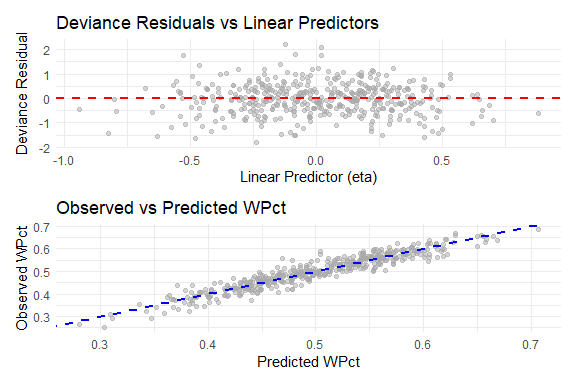

## Python

``` python
# 예측값과 잔차를 데이터에 추가
teams_diag = teams_filtered.copy()

teams_diag["linear_pred"] = model_logit.model.exog @ model_logit.params.to_numpy()
teams_diag["dev_resid"] = model_logit.resid_deviance
teams_diag["pred_WPct"] = model_logit.fittedvalues

# ii. Deviance residuals vs linear predictors 산점도
plot_resid = (
    ggplot(teams_diag, aes(x="linear_pred", y="dev_resid"))
    + geom_point(alpha=0.5, color="darkgray")
    + geom_hline(yintercept=0, linetype="dashed", color="red", size=1)
    + labs(
        title="Deviance Residuals vs Linear Predictors",
        x="Linear Predictor (eta)",
        y="Deviance Residual"
    )
    + theme_minimal()
)

# iii. 관측된 WPct vs 예측된 WPct 산점도
plot_pred = (
    ggplot(teams_diag, aes(x="pred_WPct", y="WPct"))
    + geom_point(alpha=0.5, color="darkgray")
    + geom_abline(intercept=0, slope=1, linetype="dashed", color="blue", size=1)
    + labs(
        title="Observed vs Predicted WPct",
        x="Predicted WPct",
        y="Observed WPct"
    )
    + theme_minimal()
)

# 두 그래프를 나란히 출력
plot_resid_pw = pw.load_ggplot(plot_resid, figsize=(6, 4))
plot_pred_pw = pw.load_ggplot(plot_pred, figsize=(6, 4))

diagnostic_plot = plot_resid_pw / plot_pred_pw

diagnostic_plot.savefig("figure/diagnostic_plot.png")
```

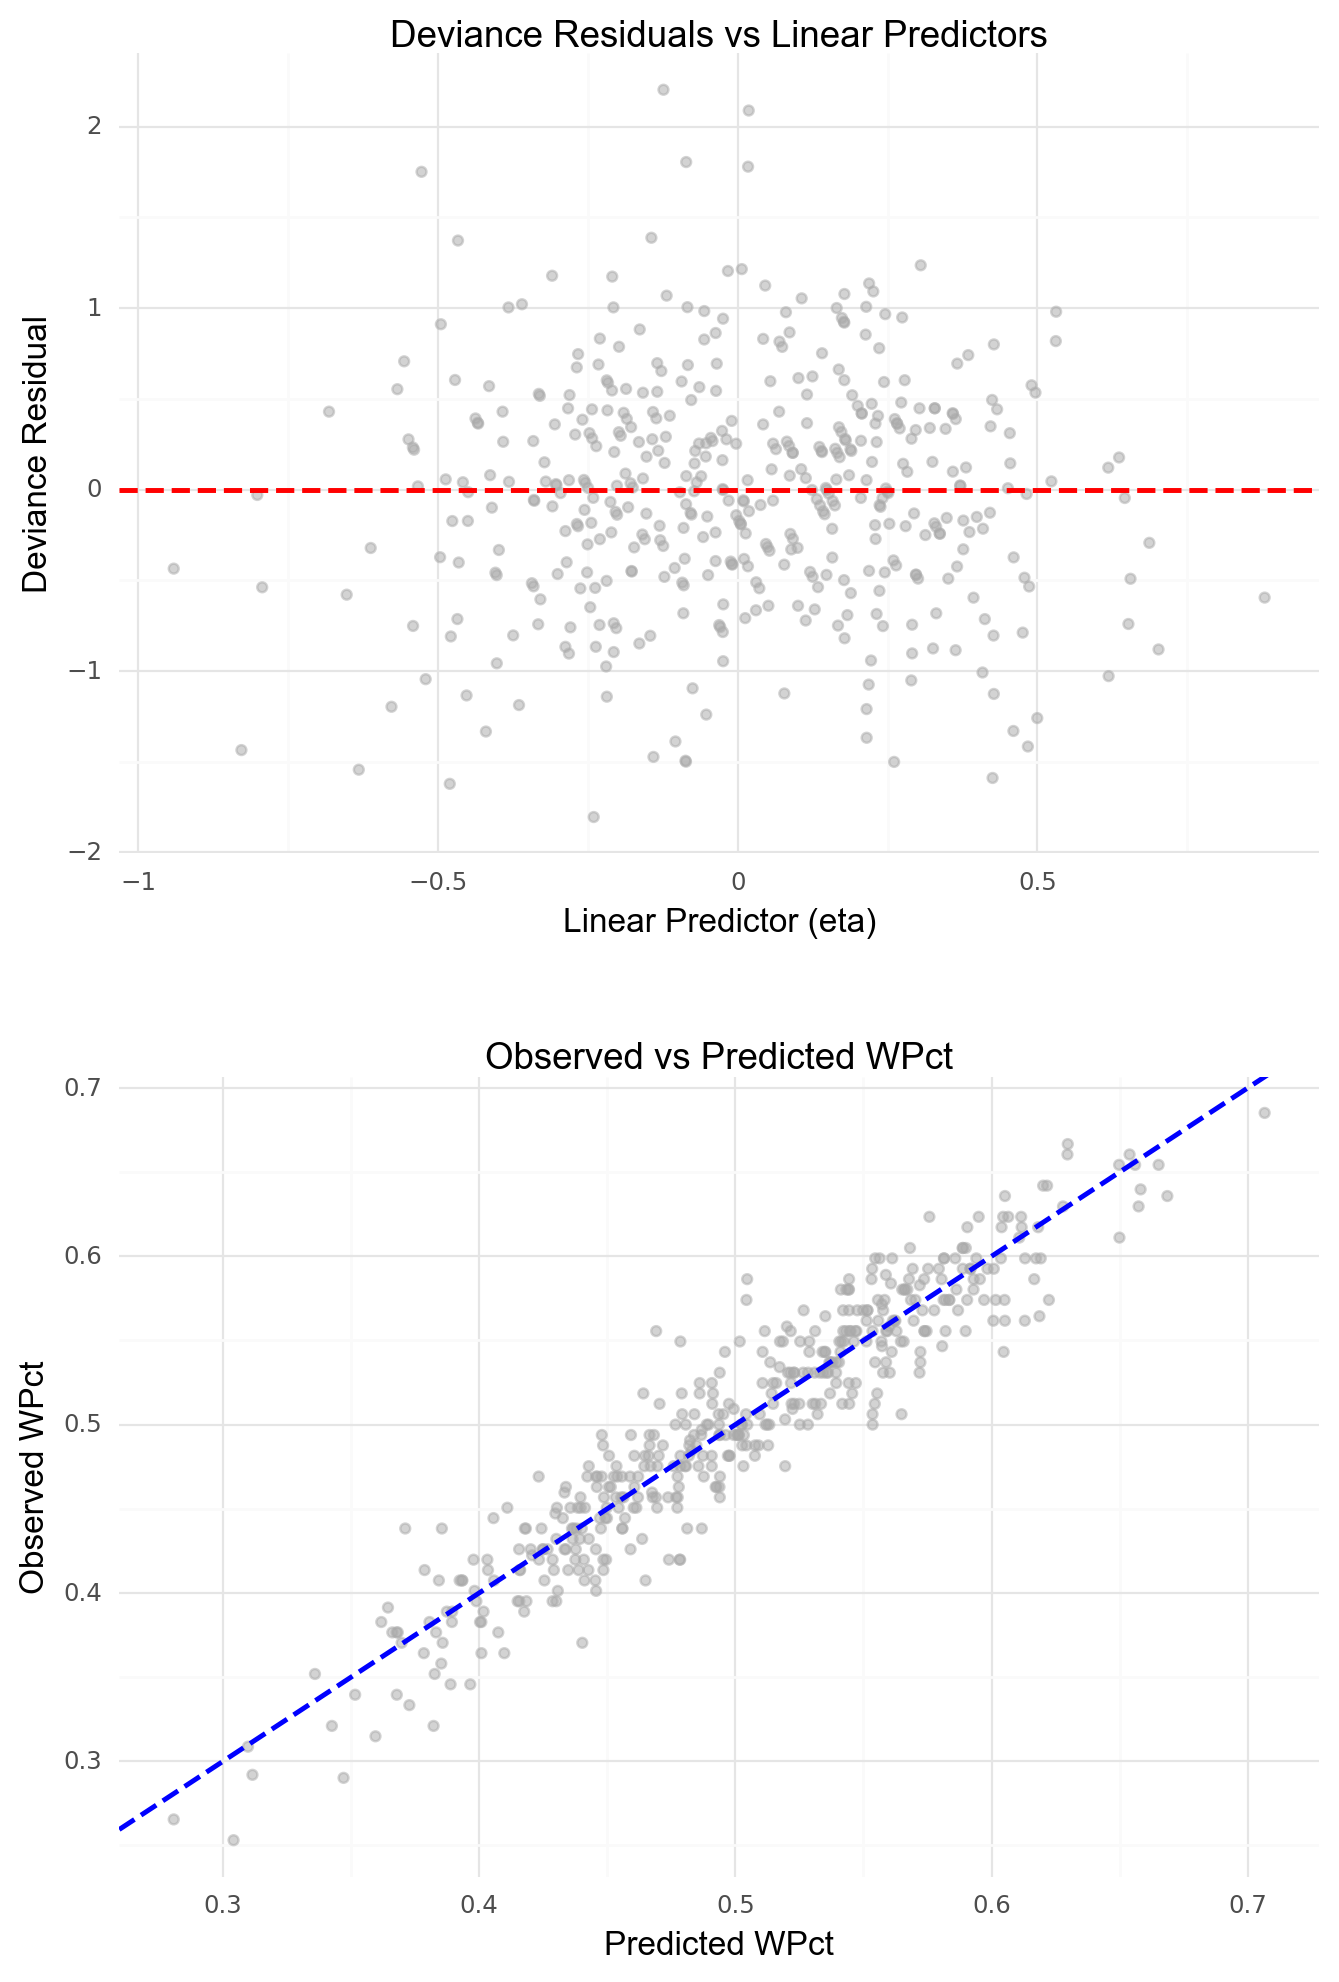

- Deviance residuals vs linear predictors ($\eta$) 산점도
  - 해석 기준 : 선형 예측값(X축)의 변화에 따른 이탈도 잔차(Y축)의 분포를
    확인하는 그래프이다. 점들이 붉은색 점선(y=0)을 중심으로 무작위로
    흩어져 있어야 모형이 잘 적합된 것이다.
  - 결과 : 점들이 없이 무작위하게 분포하고 있다. 특정한 곡선 패턴이나
    이분산성(분산이 달라지는 현상)이 관찰되지 않으므로, 잔차의 관점에서
    로지스틱 회귀 모형이 데이터에 아주 잘 적합되었다라고 판단할 수 있다.
- 관측된 WPct와 모형에서 예측하는 WPct를 산점도 그래프로 비교
  - 해석 기준 : Observed vs Predicted WPct (오른쪽 그래프)해석 기준:
    모형이 예측한 승률(X축)과 실제 관측된 승률(Y축)을 비교하는
    그래프이다. 완벽한 모형이라면 예측값과 실제값이 완전히 일치하므로
    점들이 기울기가 1인 45도 파란색 점선($y=x$) 위에 놓이게 된다.
  - 결과 : 점들이 $y=x$대각선을 따라 매우 조밀하게 밀집되어 있다. 특정
    구간에서 크게 벗어나는 편향 없이, 모형이 추정한 승률이 실제 승률을
    훌륭하게 예측하고 있다.
- 결론: 두 그래프 결과와 Residual Deviance 검정 결과를 종합해 보면,
  로지스틱 회귀 모형이 데이터에 매우 잘 적합되었다고 판단할 수 있다.

------------------------------------------------------------------------

1.  `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 하는 절편이
    없는 로지스틱선형회귀 모형을 적합하고 회귀계수들의 추정 결과를 a와
    b항의 결과와 비교하라. (유사한 모형을 얻는지 여부 등)

### 답안

- 먼저 a와 b항이 1번에서 적합한 모형과 2번에서 적합한 모형으로
  생각하겠다.

- 4번은 요구되는 모형은 다음과 같다.
  $$\operatorname{logit}(W P c t)=\beta_{R A} \log (R A)+\beta_{R S} \log (R S)$$

- 2번의 모형
  $\operatorname{logit}(W P c t)=\beta_1 \cdot \log\left(\frac{RS}{RA}\right)$과
  비교해 볼 때, 4번 모형이 2번 모형과 유사하다면 다음 관계가 성립해야
  한다.
  $$\beta_{R S} \approx k, \quad \beta_{R A} \approx -k$$

- 4번 모형을 적합시켜보고, $\log(RS)$의 계수가 양수이고, $\log(RA)$ 의
  계수가 음수이며, 두 계수의 절댓값이 1 번의 $k, 2$ 번의 $\beta_1$ 과
  비슷한지를 확인하면 된다.

## R

``` r
# 변수 추가
teams_model4 <- teams_filtered %>%
  mutate(
    log_RA = log(RA),
    log_RS = log(RS)
  )

# 모형 적합
# `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로 
model_logit_rs_ra <- glm(
  WPct ~ 0 + log_RA + log_RS,
  family = binomial(link = "logit"),
  weights = W + L,
  data = teams_model4
)

# 추정 결과 저장
summary_coef_model4 <- summary(model_logit_rs_ra)$coefficients
conf_intervals_model4 <- suppressMessages(confint(model_logit_rs_ra))

model4_results <- data.frame(
    summary_coef_model4,
    conf_intervals_model4
)

# 열 이름 및 행 이름 정리
colnames(model4_results) <- c("Estimate", "Std_Error", "z_value", "Pr(>|z|)", "CI_2.5%", "CI_97.5%")
rownames(model4_results) <- c("beta_RA", "beta_RS")
```

## Python

``` python
# 변수 추가
teams_filtered = pl.from_pandas(teams_filtered)
teams_model4 = (
    teams_filtered
    .with_columns([
        pl.col("RA").log().alias("log_RA"),
        pl.col("RS").log().alias("log_RS")
    ])
)

# statsmodels에서 모형을 적합하기 위해 pandas 데이터프레임으로 변환
teams_model4 = teams_model4.to_pandas()

# 모형 적합
# `WPct`를 반응변수로, `log(RA)`와 `log(RS)`를 설명변수로
model_logit_rs_ra = smf.glm(
    formula="WPct ~ 0 + log_RA + log_RS",
    data=teams_model4,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
    var_weights=teams_model4["W"] + teams_model4["L"]
).fit()

# 추정 결과 저장
summary_coef_model4 = pd.DataFrame({
    "Estimate": model_logit_rs_ra.params,
    "Std_Error": model_logit_rs_ra.bse,
    "z_value": model_logit_rs_ra.tvalues,
    "Pr(>|z|)": model_logit_rs_ra.pvalues
})

conf_intervals_model4 = model_logit_rs_ra.conf_int()
conf_intervals_model4.columns = ["CI_2.5%", "CI_97.5%"]

model4_results = pd.concat(
    [summary_coef_model4, conf_intervals_model4],
    axis=1
)

# 열 이름 및 행 이름 정리
model4_results.columns = ["Estimate", "Std_Error", "z_value", "Pr(>|z|)", "CI_2.5%", "CI_97.5%"]
model4_results.index = ["beta_RA", "beta_RS"]
```

- 이제 1번의 k, 2번의 $\beta_1$, 그리고 4번 모형에서 얻은 추정 결과를
  다시 출력하여 비교해보자.

## R

``` r
output_text <- paste0(
    "Summary of nls_output\n",
    paste(capture.output(print(round(nls_results, 4))), collapse = "\n"), "\n",
    "Summary of Logistic Regression (No Intercept)\n",
    paste(capture.output(print(round(logit_results, 4))), collapse = "\n"), "\n",
    "Summary of Model 4\n",
    paste(capture.output(print(round(model4_results, 4))), collapse = "\n"), "\n"
)
cat(output_text)
```

    Summary of nls_output
      Estimate Std_Error t_value Pr(>|t|) CI_2.5% CI_97.5%
    k   1.7528    0.0293 59.7302        0  1.6952   1.8106
    Summary of Logistic Regression (No Intercept)
           Estimate Std_Error z_value Pr(>|z|) CI_2.5% CI_97.5%
    beta_1   1.7532    0.0456 38.4329        0  1.6639   1.8427
    Summary of Model 4
            Estimate Std_Error  z_value Pr(>|z|) CI_2.5% CI_97.5%
    beta_RA  -1.7536    0.0456 -38.4305        0 -1.8431  -1.6642
    beta_RS   1.7532    0.0456  38.4307        0  1.6638   1.8426

## Python

``` python
output_text = f"""Summary of nls_output
{nls_results.round(4).to_string()}
Summary of Logistic Regression (No Intercept)
{logit_results.round(4).to_string()}
Summary of Model 4
{model4_results.round(4).to_string()}
"""

print(output_text)
```

    Summary of nls_output
       Estimate  Std_Error  t_value  Pr(>|t|)  CI_2.5%  CI_97.5%
    k    1.7528     0.0293  59.7302       0.0   1.6951    1.8105
    Summary of Logistic Regression (No Intercept)
            Estimate  Std_Error  z_value  Pr(>|z|)  CI_2.5%  CI_97.5%
    beta_1    1.7532     0.0456  38.4329       0.0   1.6638    1.8426
    Summary of Model 4
             Estimate  Std_Error  z_value  Pr(>|z|)  CI_2.5%  CI_97.5%
    beta_RA   -1.7536     0.0456 -38.4305       0.0  -1.8430   -1.6641
    beta_RS    1.7532     0.0456  38.4307       0.0   1.6637    1.8426

- 4번 모형에서 `beta_RA`의 추정치는 $-1.7536$, `beta_RS`의 추정치는
  1.7532로 나타난다. 즉, 실점(RA)이 증가하면 승률의 로짓값은 감소하고,
  득점(RS)이 증가하면 승률의 로짓값은 증가한다.
- `beta_RS`의 추정치는 1번 모형에서 $k=1.7528$, 2번 모형에서 추정한
  $\beta_1=1.7532$와 거의 동일하다. 따라서 득점 증가가 승률에 미치는
  효과는 앞선 두 모형의 결과와 매우 유사한 것으로 보인다.
- `beta_RA`의 추정치는 부호만 반대일 뿐 절댓값이 1번의 $k$, 2번의
  $\beta_1$과 거의 같다. 이는 실점 증가가 승률에 미치는 부정적인 효과가
  득점 증가의 긍정적인 효과와 거의 대칭적으로 작용한다는 것을 의미한다.
- 4번 모형의 신뢰구간을 보면 `beta_RA`의 95% 신뢰구간은 (-1.8431,
  -1.6642), `beta_RS`의 95% 신뢰구간은 (1.6638, 1.8426)이다. 두 신뢰구간
  모두 0을 포함하지 않으므로 두 회귀계수는 통계적으로 유의하다고 볼 수
  있다.
- 2번 모형의 신뢰구간과 4번 모형의 `beta_RS` 신뢰구간은 거의 완전히
  일치한다. 또한 `beta_RA`의 신뢰구간에 음수를 곱하면 대략 (1.6642,
  1.8431)이 되므로, 이 역시 2번 모형의 신뢰구간과 매우 비슷하다.
- 결론적으로 4번 모형은 log(RA)와 log(RS)의 효과를 따로 추정했음에도
  불구하고, 추정 결과가 1번과 2번의 결과와 거의 동일하게 나타난다.
  따라서 이 데이터에서는 승률이 득점과 실점의 개별적인 크기보다는
  log(RS/RA), 즉 득실점 비율에 의해 잘 설명되는 것으로 보인다.

------------------------------------------------------------------------

## 문제 2-2

`WPct`를 반응변수로, `logRS`, `logRA`, `H`, `X2B`, `X3B`, `HR`, `BB`,
`SO`, `CS`, `HBP`, `SF`, `ERA`, `CG`, `SHO`, `IPouts`, `HA`, `HRA`,
`BBA`, `SOA`, `E`, `DP`, `FP`, `SV`를 설명변수로 하는 절편항이 있는
로지스틱 회귀 모형을 적합하고 AIC를 기준으로 하는 단계별(stepwise)
변수선택을 적용하라. 변수선택 후 남은 변수들을 모두 모형에 남길지 일부를
제거할지 다시 판단하라. 최종적으로 선택된 모형을 문제1의 모형과
비교하라.

### 답안

- AIC를 기준으로한 Stepwise 변수 선택을 수행하되, 기존 `문제2-1`을
  참고하여, 2010년부터 2025년 사이의 데이터 중 코로나 시즌인 2020년을
  제외하는 전처리 과정을 포함시킨다.

## R

``` r
df <- Teams %>%
  filter(yearID >= 2010 & yearID <= 2025 & yearID != 2020) %>%
  mutate(
    WPct = W / (W + L), 
    logRS = log(R),
    logRA = log(RA)
  )

full_model <- glm(WPct ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + 
                         HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + 
                         SOA + E + DP + FP + SV, 
                  data = df, 
                  family = binomial,
                  weights = W + L) 

step_model <- step(full_model, direction = "both", trace = 0) 

# 선택된 모형의 유의성 확인
summary(step_model)
```


    Call:
    glm(formula = WPct ~ logRS + logRA + CG + SHO + SV, family = binomial, 
        data = df, weights = W + L)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.694019   0.842064  -3.199  0.00138 ** 
    logRS        1.615284   0.071880  22.472  < 2e-16 ***
    logRA       -1.284160   0.101524 -12.649  < 2e-16 ***
    CG           0.004573   0.003014   1.517  0.12926    
    SHO          0.004669   0.002531   1.845  0.06502 .  
    SV           0.011104   0.001324   8.384  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  106.12  on 444  degrees of freedom
    AIC: 2601.4

    Number of Fisher Scoring iterations: 3

## Python

``` python
# 데이터 불러오기 및 이름 변경
Teams = pl.from_pandas(pylahman.Teams())
Teams = Teams.rename({"2B": "X2B", "3B": "X3B", "IPOuts": "IPouts"})

# 조건에 맞게 데이터 필터링 및 변수 추가
df = (
    Teams
    .filter(
        (pl.col("yearID") >= 2010) &
        (pl.col("yearID") <= 2025) &
        (pl.col("yearID") != 2020)
    )
    .with_columns([
        (pl.col("W") / (pl.col("W") + pl.col("L"))).alias("WPct"),
        pl.col("R").log().alias("logRS"),
        pl.col("RA").log().alias("logRA"),
    ])
)

predictors = [
    "logRS", "logRA", "H", "X2B", "X3B", "HR", "BB", "SO", "CS",
    "HBP", "SF", "ERA", "CG", "SHO", "IPouts", "HA", "HRA", "BBA",
    "SOA", "E", "DP", "FP", "SV"
]

# 결측치 제거 및 pandas 데이터프레임으로 변환
df = df.select(["WPct", "W", "L"] + predictors).drop_nulls().to_pandas()

# 변수 선택 함수 정의
def stepwise_selection(data, target, predictors):
    current_predictors = predictors.copy()
    
    # 모형을 적합하고 반환하는 내부 함수
    def get_model(features):
        formula = f"{target} ~ 1" if len(features) == 0 else f"{target} ~ {' + '.join(features)}"
        model = smf.glm(
            formula=formula,
            data=data,
            family=sm.families.Binomial(),
            var_weights=data["W"] + data["L"]
        ).fit()
        return model
        
    best_model = get_model(current_predictors)
    best_aic = best_model.aic
    
    while True:
        changed = False
        
        # 기존 변수 제거 탐색
        for feature in current_predictors:
            trial_features = [f for f in current_predictors if f != feature]
            model = get_model(trial_features)
            
            if model.aic < best_aic:
                best_aic = model.aic
                current_predictors = trial_features
                best_model = model
                changed = True
                
        # 제외된 변수 추가 탐색
        remaining_features = [f for f in predictors if f not in current_predictors]
        for feature in remaining_features:
            trial_features = current_predictors + [feature]
            model = get_model(trial_features)
            
            if model.aic < best_aic:
                best_aic = model.aic
                current_predictors = trial_features
                best_model = model
                changed = True
                
        # 더 이상 AIC가 개선되지 않으면 반복 종료
        if not changed:
            break
            
    return best_model, current_predictors

# 전체 모형 적합 및 변수 선택 실행
step_model, selected_vars = stepwise_selection(df, "WPct", predictors)

# 최종 결과 출력
print(step_model.summary().tables[1])
```

    ==============================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
    ------------------------------------------------------------------------------
    Intercept     -2.6940      0.842     -3.199      0.001      -4.344      -1.044
    logRS          1.6153      0.072     22.472      0.000       1.474       1.756
    logRA         -1.2842      0.102    -12.649      0.000      -1.483      -1.085
    CG             0.0046      0.003      1.517      0.129      -0.001       0.010
    SHO            0.0047      0.003      1.845      0.065      -0.000       0.010
    SV             0.0111      0.001      8.384      0.000       0.009       0.014
    ==============================================================================

- AIC를 기준으로한 Stepwise 변수 선택 결과, `logRS`, `logRA`, `CG`,
  `SHO`, `SV`가 선택되었다.
  - CG (Complete Games, 완투 경기 수)
  - SHO (Shutouts, 완봉승)
  - SV (Saves)
- `logRS`와 `logRA`는 1번에서 적합한 모형과 4번에서 적합한 모형에서 모두
  중요한 설명변수로 나타났으므로, 이 두 변수는 최종 모형에 남기겠다.
- `CG`의 경우, p-value가 0.05 이상으로 나타났고, `SHO`와 독립적인
  설명력을 가지는 변수로 보기 어려우므로, 이 변수는 최종 모형에서
  제거하겠다.

## R

``` r
final_model <- glm(WPct ~ logRS + logRA + SHO + SV, 
                        data = df, 
                        family = binomial,
                        weights = W + L)

summary(final_model)
```


    Call:
    glm(formula = WPct ~ logRS + logRA + SHO + SV, family = binomial, 
        data = df, weights = W + L)

    Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -2.359663   0.812721  -2.903  0.00369 ** 
    logRS        1.606237   0.071629  22.424  < 2e-16 ***
    logRA       -1.322064   0.098413 -13.434  < 2e-16 ***
    SHO          0.004956   0.002523   1.964  0.04955 *  
    SV           0.010697   0.001297   8.249  < 2e-16 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for binomial family taken to be 1)

        Null deviance: 1700.54  on 449  degrees of freedom
    Residual deviance:  108.42  on 445  degrees of freedom
    AIC: 2601.7

    Number of Fisher Scoring iterations: 3

``` r
output_final <- paste0(
  "Summary of Final Model\n",
  paste(capture.output(print(round(summary(final_model)$coefficients, 4))), collapse = "\n"), "\n",
  "Comparison with Model 1 based on AIC \n",
  paste(capture.output(print(round(AIC(model_bill_james, final_model), 4))), collapse = "\n"), "\n"
)

cat(output_final)
```

    Summary of Final Model
                Estimate Std. Error  z value Pr(>|z|)
    (Intercept)  -2.3597     0.8127  -2.9034   0.0037
    logRS         1.6062     0.0716  22.4244   0.0000
    logRA        -1.3221     0.0984 -13.4338   0.0000
    SHO           0.0050     0.0025   1.9638   0.0496
    SV            0.0107     0.0013   8.2491   0.0000
    Comparison with Model 1 based on AIC 
                     df       AIC
    model_bill_james  2 -2055.255
    final_model       5  2601.666

## Python

``` python
# ----------------------------------------------------
# 1. model_bill_james의 AIC 직접 계산 (curve_fit 결과용)
# ----------------------------------------------------
# (주의: 이전 셀에서 x_data, y_data, bill_james 함수, model_bill_james 배열이 
# 이미 선언되어 있어야 정상 작동합니다.)

# 예측값과 잔차(residuals) 계산
predictions = bill_james(x_data, *model_bill_james)
residuals = y_data - predictions

# 잔차제곱합(SSR)과 관측치 수(n) 계산
ssr = np.sum(residuals**2)
n = len(y_data)

# 정규 오차를 가정할 때의 로그우도(Log-Likelihood) 공식
log_likelihood = -(n / 2) * (np.log(2 * np.pi) + np.log(ssr / n) + 1)

# Bill James 모형의 파라미터 수: k 파라미터 1개 + 오차 분산 1개 = 총 2개
bj_df = 2 

# AIC 계산 공식: -2 * log_likelihood + 2 * df
bj_aic = -2 * log_likelihood + 2 * bj_df


# ----------------------------------------------------
# 2. 최종 로지스틱 모형 적합 (final_model)
# ----------------------------------------------------
final_model = smf.glm(
    formula="WPct ~ logRS + logRA + SHO + SV",
    data=df,
    family=sm.families.Binomial(),
    var_weights=df["W"] + df["L"]
).fit()


# ----------------------------------------------------
# 3. 계수(Coefficients) 결과를 소수점 4자리로 정리
# ----------------------------------------------------
summary_final = pd.DataFrame({
    "Estimate": final_model.params,
    "Std. Error": final_model.bse,
    "z value": final_model.tvalues,
    "Pr(>|z|)": final_model.pvalues
}).round(4)


# ----------------------------------------------------
# 4. AIC 비교표 생성
# ----------------------------------------------------
final_df = int(final_model.df_model + 1)
final_aic = final_model.aic

aic_comparison = pd.DataFrame({
    "df": [bj_df, final_df],
    "AIC": [round(bj_aic, 4), round(final_aic, 4)]
}, index=["model_bill_james", "final_model"])


# ----------------------------------------------------
# 5. 결과 문자열 결합 및 최종 출력
# ----------------------------------------------------
output_final = (
    "Summary of Final Model\n"
    f"{summary_final.to_string()}\n\n"
    "Comparison with Model 1 based on AIC\n"
    f"{aic_comparison.to_string()}\n"
)

print(output_final)
```

    Summary of Final Model
               Estimate  Std. Error  z value  Pr(>|z|)
    Intercept   -2.3597      0.8127  -2.9034    0.0037
    logRS        1.6062      0.0716  22.4244    0.0000
    logRA       -1.3221      0.0984 -13.4338    0.0000
    SHO          0.0050      0.0025   1.9638    0.0496
    SV           0.0107      0.0013   8.2491    0.0000

    Comparison with Model 1 based on AIC
                      df         AIC
    model_bill_james   2  -2055.2548
    final_model        5  65035.3400

- 최종 모형의 적합 결과, 모든 변수의 p-value가 0.05 미만으로 나타났다.
- 특히, `SHO`의 p-value가 `CG`를 제거한 후 0.05 미만으로 나타나면서,
  완봉승이 승률 예측에 중요한 설명변수로 나타났다.
- 하지만, 모형 1에서 적합한 모형과 비교해 보면, 최종 모형의 AIC가 1번
  모형의 AIC보다 훨씬 낮게 나타난다.
- 해당 결과는 야구에서 기타 변수(세이브 등)를 복잡하게 추가하여 분석하는
  것보다, 단순히 득점과 실점의 비율만 활용한 조정된 빌 제임스의 기대
  승률 모형이 승률 예측에 훨씬 강력하고 적합하다고 볼 수 있다.

## 문제 2-3

1.  `W`(승리 횟수)를 반응변수로 하여 문제 2-2의 분석을 실시하되 포아송
    회귀모형을 사용하라. 결과를 문제 2-2의 모형과 비교하라.

### 답안

- AIC를 기준으로한 Stepwise 변수 선택을 수행하되, 기존 `문제2-1`을
  참고하여, 2010년부터 2025년 사이의 데이터 중 코로나 시즌인 2020년을
  제외하는 전처리 과정을 포함시킨다.

## R

``` r
# 파생 변수 생성
df <- Teams %>%
  filter(yearID >= 2010 & yearID <= 2025 & yearID != 2020) %>%
  mutate(
    logRS = log(R),
    logRA = log(RA)
  )

# 포아송 회귀 모형 적합
full_poisson <- glm(W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + 
                        HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + 
                        SOA + E + DP + FP + SV, 
                    data = df, 
                    family = poisson)

# 단계별 변수 선택
step_poisson <- step(full_poisson, direction = "both", trace = 0)

# 선택된 모형 확인
summary(step_poisson)
```


    Call:
    glm(formula = W ~ logRS + ERA + CG + E + SV, family = poisson, 
        data = df)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.3757640  0.3476706  -1.081    0.280    
    logRS        0.7921194  0.0507212  15.617  < 2e-16 ***
    ERA         -0.1534248  0.0134578 -11.400  < 2e-16 ***
    CG           0.0033842  0.0020730   1.633    0.103    
    E           -0.0006008  0.0003532  -1.701    0.089 .  
    SV           0.0056969  0.0009280   6.139 8.29e-10 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 865.249  on 449  degrees of freedom
    Residual deviance:  62.294  on 444  degrees of freedom
    AIC: 2874.2

    Number of Fisher Scoring iterations: 3

## Python

``` python
print("Hello, World!")
```

    Hello, World!

- AIC를 기준으로한 Stepwise 변수 선택 결과, `logRS`, `ERA`, `CG`, `E`,
  `SV`가 선택되었다.
  - ERA (Earned Run Average, 평균자책점)
  - CG (Complete Games, 완투 경기 수)
  - E (Errors, 실책 수)
  - SV (Saves)
- `logRS`는 득점 증가가 승리 횟수 증가에 긍정적인 영향을 미치는 중요한
  설명변수로 나타났으므로, 이 변수는 최종 모형에 남기겠다.
- `ERA`의 경우, p-value가 0.05 미만으로 나타났고, 변수의 의미를 고려했을
  때 `log_RA`를 반영하는 변수로 볼 수 있으므로, 이 변수는 최종 모형에
  남기겠다.
- `E`의 경우, p-value가 0.05 이상으로 나타났고, 변수의 의미를 고려했을
  때 `ERA`와 관련된 변수로 볼 수 있으므로, 이 변수는 최종 모형에서
  제거하겠다.
- `CG`의 경우, p-value가 0.05 이상으로 나타났으므로, 이 변수는 최종
  모형에서 제거하겠다.
- `SV`의 경우, p-value가 0.05 미만으로 나타났으므로, 이 변수는 최종
  모형에 남기겠다.

## R

``` r
# 최종 모형 적합
final_poisson <- glm(W ~ logRS + ERA + SV, 
                     data = df, 
                     family = poisson)

# 최종 모형 확인
summary(final_poisson)
```


    Call:
    glm(formula = W ~ logRS + ERA + SV, family = poisson, data = df)

    Coefficients:
                  Estimate Std. Error z value Pr(>|z|)    
    (Intercept) -0.4333318  0.3304837  -1.311     0.19    
    logRS        0.8023839  0.0495350  16.198  < 2e-16 ***
    ERA         -0.1639916  0.0124345 -13.188  < 2e-16 ***
    SV           0.0053838  0.0009051   5.949 2.71e-09 ***
    ---
    Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

    (Dispersion parameter for poisson family taken to be 1)

        Null deviance: 865.249  on 449  degrees of freedom
    Residual deviance:  67.326  on 446  degrees of freedom
    AIC: 2875.2

    Number of Fisher Scoring iterations: 3

``` r
# 모델 비교 출력
output_compare <- paste0(
    "Summary final_poisson \n",
    paste(capture.output(print(round(summary(final_poisson)$coefficients, 4))), collapse = "\n"), "\n",
    "AIC Comparison\n",
    "Logistic Model AIC: ", round(AIC(final_model), 4), "\n",
    "Poisson Model AIC: ", round(AIC(final_poisson), 4), "\n"
)
cat(output_compare)
```

    Summary final_poisson 
                Estimate Std. Error  z value Pr(>|z|)
    (Intercept)  -0.4333     0.3305  -1.3112   0.1898
    logRS         0.8024     0.0495  16.1983   0.0000
    ERA          -0.1640     0.0124 -13.1884   0.0000
    SV            0.0054     0.0009   5.9485   0.0000
    AIC Comparison
    Logistic Model AIC: 2601.6661
    Poisson Model AIC: 2875.1854

## Python

``` python
print("Hello, World!")
```

    Hello, World!

- 최종 모형의 적합 결과, 세 변수 (`logRS`, `ERA`, `SV`)의 p-value가 모두
  0.05 미만으로 나타났다.
- AIC 비교 결과, `문제 2-2` 모형의 AIC 수치가 더 낮지만, `문제 2-2`
  모형은 승률(비율)을, 포아송 모형은 승리 횟수(카운트)를 반응변수로
  사용하여 척도와 분포가 다르므로 두 모형의 우위를 AIC로 직접 비교하는
  것은 적절하지 않다.
- 다만 두 분석 모두 공격과 투수력을 대표하는 지표가 핵심 변수로
  도출되었다는 공통점을 확인할 수 있다.

------------------------------------------------------------------------

1.  `W`를 반응변수로 하여 문제2의 분석을 실시하되 음이항 회귀모형을
    사용하라. 모형 적합 시 오류가 발생하면 이유를 파악해서 보고하라.

### 답안

- 문제에서 `문제2` 분석이라고 언급한 것은 `문제 2-2`의 분석을 의미하는
  것으로 보인다.
- 분산이 평균보다 큰 계수 자료 분석에서 유용한 음이항 회귀모형을
  적합하되, 강의 내용을 참고하여 `MASS` 패키지의 `glm.nb()` 함수를
  사용하여 모형을 적합한다.
- 음이항 회귀모형은 데이터의 분산이 평균보다 큰
  과대산포(overdispersion)를 다루기 위해 고안된 모형이다.
- 과소산포가 존재하는 경우, `iteration 제한에 도달했습니다`라는 경고가
  뜨면서 음이항 회귀모형이 정상적으로 적합되지 않을 수 있다.

## R

``` r
# 음이항 회귀모형
full_nb <- MASS::glm.nb(W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + 
                            HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + 
                            SOA + E + DP + FP + SV, 
                        data = df)

warnings()[1]
```

    Warning message:

## Python

``` python
print("Hello, World!")
```

    Hello, World!

- 위에서 음이항 회귀모형을 적합하는 과정에서
  `iteration 제한에 도달했습니다`라는 경고가 발생하였다.
- 음이항 모형이 에러를 낸 이유를 파악하기 위해, 동일한 변수를 넣은
  포아송 회귀모형의 ’산포 비율(Dispersion Ratio = 잔차 이탈도 / 잔차
  자유도)’을 계산해 보자.
- 산포 비율이 1에 가까워야 정상이지만, 1보다 훨씬 작은 값이
  도출되었다면, 데이터가 과소산포(underdispersion) 상태에 있음을
  시사한다.

## R

``` r
# 동일한 변수로 포아송 모형 적합 (이전 문제 코드 재사용)
full_poisson <- glm(W ~ logRS + logRA + H + X2B + X3B + HR + BB + SO + CS + 
                        HBP + SF + ERA + CG + SHO + IPouts + HA + HRA + BBA + 
                        SOA + E + DP + FP + SV, 
                    data = df, 
                    family = poisson)

# 잔차 이탈도와 자유도를 나누어 산포 비율 계산
dispersion_ratio <- full_poisson$deviance / full_poisson$df.residual

# 산포 비율 출력
cat("Dispersion Ratio :", dispersion_ratio, "\n")
```

    Dispersion Ratio : 0.1308211 

## Python

``` python
print("Hello, World!")
```

    Hello, World!

- 현재 Dispersion Ratio가 0.13으로 나타나, 1보다 훨씬 작은 값을 보이고
  있다. 이는 데이터가 과소산포(underdispersion) 상태에 있음을 시사한다.
- 음이항 회귀모형은 기본적으로 분산이 평균보다 큰
  과대산포(Overdispersion) 상황을 해결하기 위해 사용하는 모형이다.
- 이전 문제들의 분석 결과를 참고하여 추측해보면, 현재 모형에는 반응
  변수(`W`)를 거의 완벽하게 설명할 수 있는 설명 변수들을 포함되었다.
- 변수들이 종속변수의 움직임을 100% 가깝게 설명해 버리면서, 오히려
  모형이 설명하고 잔차의 분산이 평균보다 극단적으로 작아지는 **조건부
  과소산포(Conditional Underdispersion)**가 발생했다. (산포 비율이 1보다
  훨씬 작다는 것이 그 증거이다.)
- 결과적으로, 과대산포를 찾는 glm.nb() 알고리즘이 오히려 분산이 쪼그라든
  과소산포 데이터에서 존재하지 않는 모수(파라미터)를 찾으려다 무한
  루프를 돌고 수렴에 실패한 것으로 추측된다.

## 문제 2-4

스테로이드 시대인 1994년에서 2005년의 기간과 최근 시대인 2010년에서 2025
기간의 $k$ 계수가 유의하게 변화하는지 파악하기 위해 $i$번째 팀과 연도
$t$에 대해 다음과 같은 식을 생각해 볼 수 있다.
$$  WPct_(i,t)
  =
  \frac{1}{1+(RA_{i,t}/RS_{i,t} )^{k+g I(1994 \leq t \leq 2005)} }$$
이 때 $I(1994 \leq t \leq 2005)$는 괄호안의 조건이 만족되면 1의 값을
가지고 아니면 0의 값을 가지는 지시함수이고, $g$는 스테로이드 시대와 최근
시대의 차이를 나타내는 계수이다. 위의 식에서 $g$가 0과 유의하게 같은지
가설검정을 수행하게 해주는 로지스틱 모형을 적합하고 결과를 해석하라.
(코로나 시즌인 2020년은 제외한다.)

### 답안

# 3부 데이터 분석 기술

숙제 2에서는 제출용 GitHub 저장소에 작업한 Quarto markdown 소스
파일(`hw02.qmd`)을 올리면 GitHub에서 자동으로 HTML 파일 및 주피터 노트북
파일(`.ipynb`)을 만들고 이것을 [GitHub
Pages](https://docs.github.com/en/pages/quickstart)에서 웹페이지로
보이도록 설정하였다. 여기서는 숙제 3 제출용 GibHub 저장소에 작업한
Quarto markdown 소스 파일(`hw03.qmd`)을 올리면 숙제 2에서의 작업
프로세스에 더해 자동 생성된 `.ipynb` 파일을 컨테이너화하여, GitHub에서
자동 생성된 컨테이너 이미지를 Binder 서비스를 이용하여 온라인에서 주피터
노트북 파일을 사용할 수 있도록 한다.

## 문제 3-1. Dockerfile 설정

로컬 저장소 최상위 디렉토리에 아래와 같은 `Dockerfile` 파일을 추가한다.

In [ ]:
# 1. 기반 이미지 설정
FROM rocker/tidyverse:4.4.0

# 2. 시스템 의존성 설치 (ImageMagick 포함)
USER root
RUN apt-get update && apt-get install -y \
    wget \
    git \
    imagemagick \
    libmagick++-dev \
    && rm -rf /var/lib/apt/lists/*

# 3. Miniconda 설치
ENV CONDA_DIR /opt/conda
RUN wget --quiet https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O ~/miniconda.sh && \
    /bin/bash ~/miniconda.sh -b -p /opt/conda && \
    rm ~/miniconda.sh

# 4. Conda 경로 설정 및 환경 생성
ENV PATH=$CONDA_DIR/bin:$PATH
RUN conda create -n r-reticulate python=3.10 -y && \
    conda install -n r-reticulate -c conda-forge numpy pandas matplotlib -y
# 추가로 필요한 패키지 설치

# 5. R 패키지 설치 (reticulate 및 필수 패키지)
RUN R -e "install.packages(c('reticulate', 'remotes', 'IRkernel'))" && \
    R -e "IRkernel::installspec(user = FALSE)"
# 추가로 필요한 패키지 설치

# 6. reticulate가 사용할 Python 경로 고정 (환경 변수)
ENV RETICULATE_PYTHON=/opt/conda/envs/r-reticulate/bin/python

# 7. Binder용 jovyan 유저 생성
ENV NB_USER=jovyan
ENV NB_UID=1000
RUN usermod -l ${NB_USER} rstudio && \
    usermod -d /home/${NB_USER} -m ${NB_USER} && \
    chown -R ${NB_USER} /opt/conda /home/${NB_USER}
    
# 8. 노트북 파일 복사
COPY _site/hw03.ipynb /home/${NB_USER}/hw03.ipynb
RUN chown ${NB_USER}:users /home/${NB_USER}/hw03.ipynb

USER ${NB_USER}
WORKDIR /home/${NB_USER}

# Binder가 기대하는 포트
EXPOSE 8888


### 답안

## 문제 3-2. GitHub Actions 워크플로우 수정

숙제 2에서 만들었던 `publish.yml`을 수정하여 기존의 배포 단계 끝에
Docker 컨테이너 이미지를 빌드하고 Github Container Registry (GHCR)에
푸시하는 단계를 추가한다.

In [ ]:
# ... (기존 Quarto Render 단계 이후)

      - name: Log in to GitHub Container Registry
        uses: docker/login-action@v3
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}

      - name: Build and push Docker image
        uses: docker/build-push-action@v5
        with:
          context: .
          push: true
          tags: ghcr.io/${{ github.repository_owner }}/my-r-env:latest

### 답안

## 문제 3-3. GitHub Pages에 Binder 링크 추가

GitHub Page를 사용하여 저장소를 웹페이지로 활용하는 부분은 숙제 2에서와
같다.

웹페이지에서 노트북을 내려받는 대신 [Binder](mybinder.org) 서비스를
이용하여 온라인으로 노트북을 실행할 수 있도록 위해 `README.md` 파일을
로컬 저장소 최상위 디렉토리에 다음과 같이 만들자.

In [ ]:
# 숙제 3

이름: [아무개]
학번: [나의 학번]

이 숙제의 상세 분석 결과는 아래 링크에서 확인하실 수 있습니다.

* [분석 리포트 (HTML)](./hw03.html) 
* [주피터 노트북 (ipynb)](https://mybinder.org/v2/gh/<유저명>/snu-stat/<repo명>/gh-pages?filepath=hw03.ipynb

여기서 `<유저명>`은 제출자의 GitHub 유저 아이디이며, `<repo명>`은 hw3-로
시작하는 제출자의 repository 이름이다.

작업을 GitHub 원격 저장소로 push한 후 숙제 2 문제 3-3의 3, 4번 과정을
반복하라.

### 답안